# Utqiagvik **Fall Sea Ice** Analysis
- Bowhead whale hunting happens in fall (September/October/November) and is dependent on sea ice conditions (Hansen et al. 2013).
- Notebook by Alice DuVivier (NCAR)
- January 2026

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from glob import glob
import pop_tools
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy
import cartopy.crs as ccrs
import cmocean
import geopandas as gpd

## Load Data

In [2]:
# set model to load
# options: 'cesm1le', 'cesm2le', 'cesm2cmip5','mesaclip'
model = 'mesaclip'

In [3]:
# set base directory
dir_base = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/'

In [4]:
# set path for files

if model == 'cesm2le':
    dir_in = dir_base+'cesm2-le_utqiagvik/'
elif model == 'cesm1le':
    dir_in = dir_base+'cesm1-le_utqiagvik/'
elif model == 'cesm2cmip5':
    dir_in = dir_base+'cesm2-cmip5_utqiagvik/'
elif model == 'mesaclip':
    dir_in = dir_base+'mesaclip_utqiagvik/'

### Load model SIC data

In [5]:
# set file and then load data
if model == 'cesm2le':
    file_in = 'Utqiagvik_CESM2-LE_1920-2100_daily-aice_d.nc'
    ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)
elif model == 'cesm2cmip5':
    file_in = 'Utqiagvik_CESM2-CMIP5_1920-2100_daily-aice_d.nc'
    ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)
elif model == 'cesm1le':
    file_in = 'Utqiagvik_CESM1-LE_1920-2100_daily-aice_d.nc'
    ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)
elif model == 'mesaclip':
    file_in_1 = 'Utqiagvik_MESACLIP_HIST_daily-aice_d.nc'
    file_in_2 = 'Utqiagvik_MESACLIP_RCP6.0_daily-aice_d.nc'
    ds1 = xr.open_dataset(dir_in+file_in_1, decode_times=False)
    ds2 = xr.open_dataset(dir_in+file_in_2, decode_times=False)
    # concatenate datasets, but have to drop one ensemble member from future data
    ds2 = ds2.isel(member_id=slice(1,10))
    # concatenate
    ds = xr.concat([ds1,ds2],dim="time")

In [6]:
# look at dataset
ds

<xarray.Dataset> Size: 8MB
Dimensions:         (member_id: 9, time: 67525)
Coordinates:
    TLAT            (member_id) float32 36B 71.3 71.3 71.3 ... 71.3 71.3 71.3
    TLON            (member_id) float32 36B 203.1 203.1 203.1 ... 203.1 203.1
  * time            (time) int64 540kB 0 1 2 3 4 ... 36131 36132 36133 36134
Dimensions without coordinates: member_id
Data variables:
    data_pt         (member_id, time) float32 2MB 99.78 99.97 95.65 ... 0.0 0.0
    data_small_box  (member_id, time) float32 2MB 99.85 99.81 97.97 ... 0.0 0.0
    data_big_box    (member_id, time) float32 2MB 99.3 99.63 99.44 ... 0.0 0.0
Attributes:
    author:          Alice DuVivier
    date_processed:  2026-01-12
    contents:        Daily MESACLIP data for ocean point nearest Utqiagvik

In [7]:
# check out the time info - find that it's not intuitive
ds.time

# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 1920-2100 for all datasets EXCEPT mesaclip, which goes to 2104, not including leap days.

if model == 'mesaclip':
    # create full range of dates at daily frequency
    dr = pd.date_range(start='1/1/1920', end='12/31/2104', freq='D')
    # remove leap days
    dates = dr[(dr.day != 29) | (dr.month != 2)]
    # check that the # times matches above
    print(dates.shape)
else:
    # create full range of dates at daily frequency
    dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
    # remove leap days
    dates = dr[(dr.day != 29) | (dr.month != 2)]
    # check that the # times matches above
    print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(67525,)


In [8]:
# save this data, multiply by 100 if needed
if model == 'cesm2le':
    data_model_sic = ds.aice_d * 100.0
elif model == 'cesm1le':
    data_model_sic = ds.aice_d
elif model == 'cesm2cmip5':
    data_model_sic = ds.aice_d * 100.0
elif model == 'mesaclip':
    data_model_sic = ds.data_big_box
    # also crop data to end at end of 2100
    data_model_sic = data_model_sic.isel(time=slice(0,66065))

### Load model SIT data

In [9]:
# set file and then load data
if model == 'cesm2le':
    file_in = 'Utqiagvik_CESM2-LE_1920-2100_daily-hi_d.nc'
    ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)   
elif model == 'cesm2cmip5':
    file_in = 'Utqiagvik_CESM2-CMIP5_1920-2100_daily-hi_d.nc'
    ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)   
elif model == 'cesm1le':
    file_in = 'Utqiagvik_CESM1-LE_1920-2100_daily-hi_d.nc'
    ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)   
elif model == 'mesaclip':
    file_in_1 = 'Utqiagvik_MESACLIP_HIST_daily-hi_d.nc'
    file_in_2 = 'Utqiagvik_MESACLIP_RCP6.0_daily-hi_d.nc'
    ds1 = xr.open_dataset(dir_in+file_in_1, decode_times=False)
    ds2 = xr.open_dataset(dir_in+file_in_2, decode_times=False)
    # concatenate datasets, but have to drop one ensemble member from future data
    ds2 = ds2.isel(member_id=slice(1,10))
    # concatenate
    ds = xr.concat([ds1,ds2],dim="time")

In [10]:
# look at dataset
ds

<xarray.Dataset> Size: 8MB
Dimensions:         (member_id: 9, time: 67525)
Coordinates:
    TLAT            (member_id) float32 36B 71.3 71.3 71.3 ... 71.3 71.3 71.3
    TLON            (member_id) float32 36B 203.1 203.1 203.1 ... 203.1 203.1
  * time            (time) int64 540kB 0 1 2 3 4 ... 36131 36132 36133 36134
Dimensions without coordinates: member_id
Data variables:
    data_pt         (member_id, time) float32 2MB 0.747 2.157 2.326 ... 0.0 0.0
    data_small_box  (member_id, time) float32 2MB 0.8537 1.916 2.171 ... 0.0 0.0
    data_big_box    (member_id, time) float32 2MB 1.188 1.391 1.468 ... 0.0 0.0
Attributes:
    author:          Alice DuVivier
    date_processed:  2026-01-12
    contents:        Daily MESACLIP data for ocean point nearest Utqiagvik

In [11]:
# check out the time info - find that it's not intuitive
ds.time

# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 1920-2100 for all datasets EXCEPT mesaclip, which goes to 2104, not including leap days.

if model == 'mesaclip':
    # create full range of dates at daily frequency
    dr = pd.date_range(start='1/1/1920', end='12/31/2104', freq='D')
    # remove leap days
    dates = dr[(dr.day != 29) | (dr.month != 2)]
    # check that the # times matches above
    print(dates.shape)
else:
    # create full range of dates at daily frequency
    dr = pd.date_range(start='1/1/1920', end='12/31/2100', freq='D')
    # remove leap days
    dates = dr[(dr.day != 29) | (dr.month != 2)]
    # check that the # times matches above
    print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(67525,)


In [12]:
# save this data
if model == 'mesaclip':
    data_model_sit = ds.data_big_box
    # also crop data to end at end of 2100
    data_model_sic = data_model_sic.isel(time=slice(0,66065))
else:
    data_model_sit = ds.hi_d

### Load Satellite SIC data

In [13]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/ssmi_cdr/'
file_in = 'Utqiagvik_SSMI_CDR_1979-2021_daily-SIC.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [14]:
# look at dataset
#ds

# check out the time info - find that it's not intuitive
ds.time

# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1979', end='12/31/2021', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(15695,)


In [15]:
data_obs_sic = ds.sic

### Load PIOMAS data

In [16]:
# directory path
dir_in = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/piomas/'
file_in = 'Utqiagvik_PIOMAS_1979-2019_daily-SIC.nc'

ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [17]:
# look at dataset
#ds

# check out the time info - find that it's not intuitive
ds.time

# to make useable time coordinate, create arrays for yyyy-mm-dd (NO LEAP!)
# We know it's daily data for 19790101-20211231, not including leap days.

# create full range of dates at daily frequency
dr = pd.date_range(start='1/1/1979', end='12/31/2019', freq='D')
# remove leap days
dates = dr[(dr.day != 29) | (dr.month != 2)]
# check that the # times matches above
print(dates.shape)

# assign the time coordinate
ds['time'] = dates

(14965,)


In [18]:
data_obs_sit = ds.sit

## Process Fall SIC data
- September, October, November only
- Timeseries: calculate means and standard deviations over all months

In [19]:
# days are all days in September, October, November
ndays = 30 + 31 + 30

### Satellite SIC

In [20]:
# years from 1979-2021
years_obs_sic = np.arange(1979,2022,1)
nyrs = len(years_obs_sic)
print(nyrs)

43


In [21]:
# subset data to just fall - September, October, November
avg_array = np.zeros([nyrs])
std_array = np.zeros([nyrs])

# loop through each year to get the data
for index, yy in enumerate(years_obs_sic):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp1 = data_obs_sic.isel(time=data_obs_sic.time.dt.year.isin([yy]))
    # get fall months only
    temp2 = temp1.isel(time=temp1.time.dt.month.isin([9,10,11]))
    # calculate mean
    avg_array[index] = temp2.mean(dim='time')
    # calculate standard deviation
    std_array[index] = temp2.std(dim='time')

In [22]:
# convert the numpy arrays to xarrays for easier plotting
obs_sic_avg = xr.DataArray(avg_array,dims=('years'))
obs_sic_avg['years'] = years_obs_sic
obs_sic_std = xr.DataArray(std_array,dims=('years'))
obs_sic_std['years'] = years_obs_sic

### PIOMAS SIT

In [23]:
# years from 1979-2020
years_obs_sit = np.arange(1979,2020,1)
nyrs = len(years_obs_sit)
print(nyrs)

41


In [24]:
# subset data to just fall - September, October, November
avg_array = np.zeros([nyrs])
std_array = np.zeros([nyrs])

# loop through each year to get the data
for index, yy in enumerate(years_obs_sit):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp1 = data_obs_sit.isel(time=data_obs_sit.time.dt.year.isin([yy]))
    # get fall months only
    temp2 = temp1.isel(time=temp1.time.dt.month.isin([9,10,11]))
    # calculate mean
    avg_array[index] = temp2.mean(dim='time')
    # calculate standard deviation
    std_array[index] = temp2.std(dim='time')

In [25]:
# convert the numpy arrays to xarrays for easier plotting
obs_sit_avg = xr.DataArray(avg_array,dims=('years'))
obs_sit_avg['years'] = years_obs_sit
obs_sit_std = xr.DataArray(std_array,dims=('years'))
obs_sit_std['years'] = years_obs_sit

## Process Fall SIC data - Model
- April and May only
- Timeseries: calculate means and standard deviations over fall months
- Time of Emergence: Use baseline 51 years (1925-1975). ToE happens when ensemble mean drops below the +/-2 STD from baseline period

In [26]:
# get some dimensions

# years from 1920-2100
years_model = np.arange(1920,2101,1)
nyrs = len(years_model)
print(nyrs)

# total ensemble members
nens = len(data_model_sic.member_id)
print(nens)

181
9


In [27]:
# subset to just this season
data_model_sic_seas = data_model_sic.isel(time=data_model_sic.time.dt.month.isin([9,10,11]))
data_model_sit_seas = data_model_sit.isel(time=data_model_sit.time.dt.month.isin([9,10,11]))

### Daily Data Means

In [28]:
# SIC
data_model = data_model_sic_seas

# preallocate some arrays
avg_array = np.zeros([nyrs])
std_array = np.zeros([nyrs])

# loop through each year to get the data
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d
    temp2 = temp1.stack(all=("member_id","time"))
    # calculate mean
    avg_array[index] = temp2.mean(dim='all')
    # calculate standard deviation
    std_array[index] = temp2.std(dim='all')

# convert the numpy arrays to xarrays for easier plotting
data_model_sic_avg = xr.DataArray(avg_array,dims=('years'))
data_model_sic_avg['years'] = years_model
data_model_sic_std = xr.DataArray(std_array,dims=('years'))
data_model_sic_std['years'] = years_model

In [29]:
# SIT
data_model = data_model_sit_seas

# preallocate some arrays
avg_array = np.zeros([nyrs])
std_array = np.zeros([nyrs])

# loop through each year to get the data
for index, yy in enumerate(years_model):
    #print(f"Index {index}: {yy}")
    # get the data for this year
    temp1 = data_model.isel(time=data_model.time.dt.year.isin([yy]))
    # make 1d
    temp2 = temp1.stack(all=("member_id","time"))
    # calculate mean
    avg_array[index] = temp2.mean(dim='all')
    # calculate standard deviation
    std_array[index] = temp2.std(dim='all')

# convert the numpy arrays to xarrays for easier plotting
data_model_sit_avg = xr.DataArray(avg_array,dims=('years'))
data_model_sit_avg['years'] = years_model
data_model_sit_std = xr.DataArray(std_array,dims=('years'))
data_model_sit_std['years'] = years_model

### Time of Emergence
- For baseline, use 50 years: 1925-1975
- ToE happens when ensemble mean drops below the +/-2 STD from baseline period

In [30]:
# subset data to just 1925-1975
yy_sub = np.arange(1925,1976,1)

In [31]:
# SIC
data_model = data_model_sic_seas
model_avg = data_model_sic_avg

### Get baseline means and standard deviation
# subset years
data_model_sub = data_model.isel(time=data_model.time.dt.year.isin([yy_sub]))
# stack into one dimension
data_model_sub_1d = data_model_sub.stack(all=("member_id","time"))
# calculate mean and standard deviation over all these points
avg_baseline = data_model_sub_1d.mean(dim='all')
print(avg_baseline.values)
std_baseline = data_model_sub_1d.std(dim='all')
print(std_baseline.values)

### Find TOE
# When ensemble mean falls **below** baseline mean **minus** 2STD
toe_thresh_hi = avg_baseline + 2*std_baseline
toe_thresh_low = avg_baseline - 2*std_baseline
# make xarray of where the output has emerged
emerged = model_avg < toe_thresh_low.values
# Check if there is a ToE
is_all_false = (emerged == False).all()
# If there is a ToE, calculate the index where it happens
if is_all_false == False:
    print('ToE exists, calculating index')
    ToE_flag = True
    first_index = emerged.argmax(dim='years')
    # calculate x and y for plot
    x_toe = emerged[first_index].years.values
    y_toe = model_avg[first_index].values
    # print the year of ToE
    print(x_toe)
else:
    print('No ToE exists')
    ToE_flag = False
    x_toe = np.full((1, 1), np.nan)
    y_toe = np.full((1, 1), np.nan)

### Write variables
data_model_sic_x_toe = x_toe
data_model_sic_y_toe = y_toe
data_model_sic_toe_thresh_hi = toe_thresh_hi.values
data_model_sic_toe_thresh_low = toe_thresh_low.values

15.866395950317383
28.32474136352539
No ToE exists


In [32]:
# SIT
data_model = data_model_sit_seas
model_avg = data_model_sit_avg

### Get baseline means and standard deviation
# subset years
data_model_sub = data_model.isel(time=data_model.time.dt.year.isin([yy_sub]))
# stack into one dimension
data_model_sub_1d = data_model_sub.stack(all=("member_id","time"))
# calculate mean and standard deviation over all these points
avg_baseline = data_model_sub_1d.mean(dim='all')
print(avg_baseline.values)
std_baseline = data_model_sub_1d.std(dim='all')
print(std_baseline.values)

### Find TOE
# When ensemble mean falls **below** baseline mean **minus** 2STD
toe_thresh_hi = avg_baseline + 2*std_baseline
toe_thresh_low = avg_baseline - 2*std_baseline
# make xarray of where the output has emerged
emerged = model_avg < toe_thresh_low.values
# Check if there is a ToE
is_all_false = (emerged == False).all()
# If there is a ToE, calculate the index where it happens
if is_all_false == False:
    print('ToE exists, calculating index')
    ToE_flag = True
    first_index = emerged.argmax(dim='years')
    # calculate x and y for plot
    x_toe = emerged[first_index].years.values
    y_toe = model_avg[first_index].values
    # print the year of ToE
    print(x_toe)
else:
    print('No ToE exists')
    ToE_flag = False
    x_toe = np.full((1, 1), np.nan)
    y_toe = np.full((1, 1), np.nan)

### Write variables
data_model_sit_x_toe = x_toe
data_model_sit_y_toe = y_toe
data_model_sit_toe_thresh_hi = toe_thresh_hi.values
data_model_sit_toe_thresh_low = toe_thresh_low.values

0.19967599213123322
0.45153138041496277
No ToE exists


## Plots

In [33]:
# set an output directory for figures
dir_out = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/utqiagvik_analysis/version_6/'

In [34]:
# set colors 
if model == 'cesm2le':
    c1 = 'royalblue'
    c2 = 'lightskyblue'
    lab = 'CESM2-LE'
    lab1 = 'c) '
    lab2 = 'd) '
elif model == 'cesm1le':
    c1 = 'firebrick'
    c2 = 'pink'
    lab = 'CESM1-LE'
    lab1 = 'a) '
    lab2 = 'b) '
elif model == 'cesm2cmip5':
    c1 = 'gold'
    c2 = 'khaki'
    lab = 'CESM2-CMIP5'
    lab1 = 'e) '
    lab2 = 'f) '
elif model == 'mesaclip':
    c1 = 'turquoise'
    c2 = 'paleturquoise'
    lab = 'MESACLIP'
    lab1 = 'g) '
    lab2 = 'h) '

# set colors for the fractional categories
cc = ['midnightblue','royalblue','cornflowerblue','skyblue','paleturquoise']

### All Panels on one Plot

In [35]:
fout = 'utq_fall_sic_timeseries_'+model

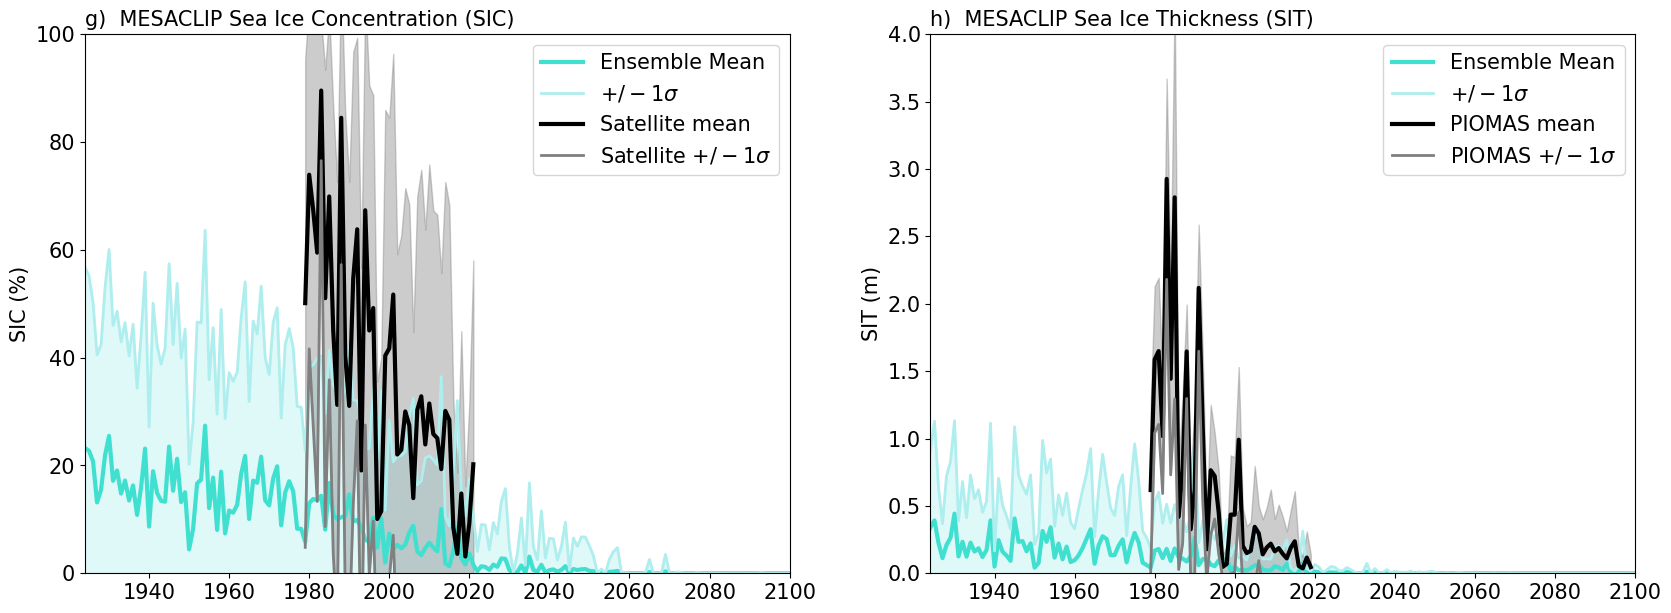

In [36]:
# create figure
#fig = plt.figure(figsize=(30,30))
fig = plt.figure(figsize=(20,7))
# now loop through months to create subpanels

# Make subplot - note it's nrow x ncol x index (starting upper left) - 3 rows x 2 columns
### Plot 1 - SIC timeseries ###
ax = fig.add_subplot(1,2,1)
# data to plot
model_avg = data_model_sic_avg
model_std = data_model_sic_std
## Model Data
ax.plot(years_model,model_avg,color=c1,label='Ensemble Mean',linestyle='-',linewidth=3)
ax.plot(years_model,model_avg - model_std,color=c2,label=r'$+/- 1 \sigma$',linestyle='-',linewidth=2)
ax.plot(years_model,model_avg + model_std,color=c2,linestyle='-',linewidth=2)
plt.fill_between(years_model, model_avg, model_avg + model_std, color=c2, alpha=0.4)
plt.fill_between(years_model, model_avg, model_avg - model_std, color=c2, alpha=0.4)
## Satellite
ax.plot(years_obs_sic,obs_sic_avg,color="black",label='Satellite mean',linestyle='-',linewidth=3)
ax.plot(years_obs_sic,obs_sic_avg-obs_sic_std,color="grey",label=r'Satellite $ +/- 1 \sigma$',linestyle='-',linewidth=2)
plt.fill_between(years_obs_sic, obs_sic_avg, obs_sic_avg+obs_sic_std, color='grey', alpha=0.4)
plt.fill_between(years_obs_sic, obs_sic_avg, obs_sic_avg-obs_sic_std, color='grey', alpha=0.4)
# modify labels and legend
plt.title(lab1+' '+lab+' Sea Ice Concentration (SIC)',loc='left',fontsize=15)
plt.xticks(fontsize=15,rotation=0)
plt.xlim([1924,2100])
plt.ylabel('SIC (%)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0,100.0])
#plt.grid()
plt.legend(loc='upper right', fontsize=15, ncol=1)

### Plot 2 - SIT timeseries ###
ax = fig.add_subplot(1,2,2)
# data to plot
model_avg = data_model_sit_avg
model_std = data_model_sit_std
toe_x = data_model_sit_x_toe
toe_y = data_model_sit_y_toe
toe_hi = data_model_sit_toe_thresh_hi
toe_lo = data_model_sit_toe_thresh_low
toe = str(toe_x)
## Model Data
ax.plot(years_model,model_avg,color=c1,label='Ensemble Mean',linestyle='-',linewidth=3)
ax.plot(years_model,model_avg - model_std,color=c2,label=r'$+/- 1 \sigma$',linestyle='-',linewidth=2)
ax.plot(years_model,model_avg + model_std,color=c2,linestyle='-',linewidth=2)
plt.fill_between(years_model, model_avg, model_avg + model_std, color=c2, alpha=0.4)
plt.fill_between(years_model, model_avg, model_avg - model_std, color=c2, alpha=0.4)
## PIOMAS
ax.plot(years_obs_sit,obs_sit_avg,color="black",label='PIOMAS mean',linestyle='-',linewidth=3)
ax.plot(years_obs_sit,obs_sit_avg-obs_sit_std,color="grey",label=r'PIOMAS $ +/- 1 \sigma$',linestyle='-',linewidth=2)
plt.fill_between(years_obs_sit, obs_sit_avg, obs_sit_avg+obs_sit_std, color='grey', alpha=0.4)
plt.fill_between(years_obs_sit, obs_sit_avg, obs_sit_avg-obs_sit_std, color='grey', alpha=0.4)
# modify labels and legend
plt.title(lab2+' '+lab+' Sea Ice Thickness (SIT)',loc='left',fontsize=15)
#plt.xlabel('year',fontsize=20)
plt.xticks(fontsize=15,rotation=0)
plt.xlim([1924,2100])
plt.ylabel('SIT (m)',fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0,4])
#plt.grid()
plt.legend(loc='upper right', fontsize=15, ncol=1)

# Finalize figure and save
fig = plt.savefig(fout+'.png', bbox_inches='tight', dpi=200)
fig = plt.savefig(dir_out+fout+'.png', bbox_inches='tight', dpi=200)